In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

BASE_DIR = "/Users/ipekgezer"
DATA_FILE = "country_year_women_ratio_vdem_multi.csv"

local_path = os.path.join(BASE_DIR, DATA_FILE)
fallback_path = "/mnt/data/country_year_women_ratio_vdem_multi.csv"
DATA_PATH = local_path if os.path.exists(local_path) else fallback_path

df = pd.read_csv(DATA_PATH)

# year filter
YEAR_MIN = 2000
if "year" in df.columns:
    df = df[df["year"] >= YEAR_MIN].copy()

score_col = "v2x_polyarchy"    # or "v2x_libdem"  
y_col = "female_ratio"

#to achive one country per row
df = df[df["year"] >= YEAR_MIN].copy()
df = df.groupby("country", as_index=False)[[score_col, y_col]].mean()

tmp = df[[score_col, y_col]].dropna().copy()

# high female representation (median split)
thr_y = tmp[y_col].median()
tmp["y_high"] = (tmp[y_col] >= thr_y).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    tmp[[score_col]].to_numpy(), tmp["y_high"].to_numpy(),
    test_size=0.2, random_state=42, stratify=tmp["y_high"].to_numpy()
)

print("female_ratio median threshold:", thr_y)
print("y_high counts:\n", tmp["y_high"].value_counts())


female_ratio median threshold: 0.1606352444530659
y_high counts:
 y_high
1    69
0    68
Name: count, dtype: int64


In [32]:
scores_train = X_train.ravel()

thresholds = np.linspace(scores_train.min(), scores_train.max(), 80)

best = {"thr": None, "f1": -1}
for thr in thresholds:
    pred_train = (scores_train >= thr).astype(int)
    f1v = f1_score(y_train, pred_train, zero_division=0)
    if f1v > best["f1"]:
        best["thr"] = float(thr)
        best["f1"] = float(f1v)

print("Best threshold on train by F1:", best["thr"])
print("Best train F1:", best["f1"])


Best threshold on train by F1: 0.4157594936708861
Best train F1: 0.72


In [33]:
scores_test = X_test.ravel()
y_pred_test = (scores_test >= best["thr"]).astype(int)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)
cm   = confusion_matrix(y_test, y_pred_test)

print("Test metrics")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)
print("Error rate (1-acc):", 1 - acc)
print("Confusion Matrix [[TN FP],[FN TP]]:\n", cm)


Test metrics
Accuracy : 0.75
Precision: 0.6842105263157895
Recall   : 0.9285714285714286
F1       : 0.7878787878787878
Error rate (1-acc): 0.25
Confusion Matrix [[TN FP],[FN TP]]:
 [[ 8  6]
 [ 1 13]]


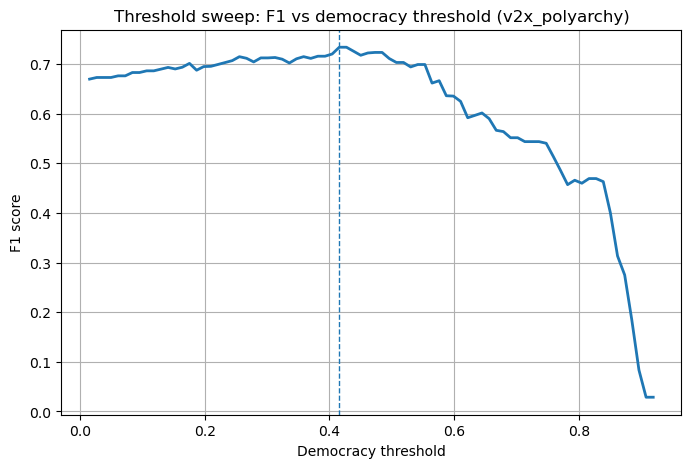

In [34]:
f1s = []
for thr in thresholds:
    pred = (tmp[score_col].to_numpy() >= thr).astype(int)
    f1s.append(f1_score(y_true, pred, zero_division=0))

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1s, linewidth=2)
plt.axvline(best["thr"], linestyle="--", linewidth=1)
plt.title(f"Threshold sweep: F1 vs democracy threshold ({score_col})")
plt.xlabel("Democracy threshold")
plt.ylabel("F1 score")
plt.grid(True)
plt.show()


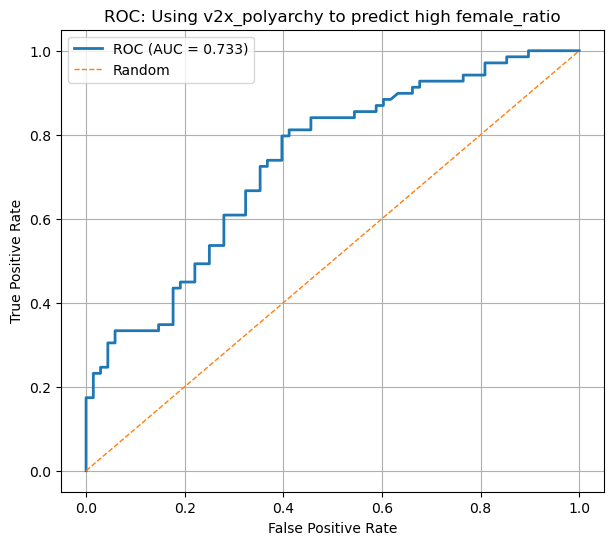

In [37]:
y_true = tmp["y_high"].to_numpy()
scores = tmp[score_col].to_numpy()  

fpr, tpr, thresholds = roc_curve(y_true, scores)
auc = roc_auc_score(y_true, scores)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.title(f"ROC: Using {score_col} to predict high female_ratio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()
